# 61: Event Study — Abnormal Returns Around Reputational Risk Peaks

Links the reputational-risk peaks detected in notebook 60 to equity market reactions.
The logic is simple: if our pipeline genuinely detects events that matter to investors,
we should observe **negative cumulative abnormal returns (CARs)** in the days following a peak.

## Design

| Parameter | Choice | Rationale |
|-----------|--------|-----------|
| Market model | OLS market model (CAPM) | Standard event-study benchmark |
| Estimation window | [−210, −11] trading days | 200 days, clean of contamination |
| Event window | [−1, +5] trading days | Covers pre-announcement leak + short-term reaction |
| Market proxy | ACWI (iShares All Country World Index) | Matches MSCI World universe |
| Test statistic | Boehmer et al. (1991) standardised cross-sectional test | Robust to event-induced variance |
| Min estimation obs | 50 trading days | Filter firms with thin history |

In [1]:
%pip install -q yfinance statsmodels

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import warnings
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
from tqdm.auto import tqdm


warnings.filterwarnings('ignore')

OUTPUT_DIR = Path('results/phase_iv')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ESTIMATION_START = -210
ESTIMATION_END   = -11
EVENT_WINDOW     = (-1, 5)
MIN_EST_OBS      = 50 # recommended by MacKinlay (1997) to ensure reliable estimates of the parameters of the market model.
MARKET_TICKER    = 'ACWI'  # MSCI World Index as market proxy; URTH is the official ETF but it only runs from 2012, so we use ACWI which has a longer history.

/home/le/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1 — Load peaks

The parquet contains peak-level fields such as `primary_category`, `dominant_emotion`,
`max_z`, and `duration_days`, which we use directly.

In [3]:
PEAKS_PATH = Path('results/phase_iii/all_peaks_loose_threshold.parquet')
all_peaks = pd.read_parquet(PEAKS_PATH)

all_peaks['start_date'] = pd.to_datetime(all_peaks['start_date'])
all_peaks['end_date'] = pd.to_datetime(all_peaks['end_date'])

print(f'max_z range: {all_peaks["max_z"].min():.3f} – {all_peaks["max_z"].max():.3f}')
print(f'Peaks      : {len(all_peaks):,}')
print(f'Companies  : {all_peaks["ticker"].nunique()}')
print(f'Columns    : {all_peaks.columns.tolist()}')

max_z range: 1.556 – 2.846
Peaks      : 1,774
Companies  : 270
Columns    : ['peak_id', 'ticker', 'start_date', 'end_date', 'duration_days', 'max_anger_z', 'max_sadness_z', 'max_fear_z', 'max_disgust_z', 'mean_anger_z', 'mean_sadness_z', 'mean_fear_z', 'mean_disgust_z', 'max_z', 'dominant_emotion', 'total_articles', 'company_name', 'total_articles_in_dataset', 'category_evolution', 'primary_category']


## Step 2 — Download price data with exchange-suffix mapping

62 tickers failed in v1 because yfinance requires exchange suffixes for non-US firms.
This cell applies a mapping covering all failed tickers identified in v1.

In [4]:
# Exchange suffix map — covers all 61 international tickers that failed in v1
TICKER_SUFFIX_MAP = {
    # Germany (Frankfurt)
    'SIE':  'SIE.DE',  'BAYN': 'BAYN.DE', 'LHA':  'LHA.DE',
    'BAS':  'BAS.DE',  'ADS':  'ADS.DE',  'VOW3': 'VOW3.DE', 'PAH3': 'PAH3.DE',
    # Switzerland
    'ZURN': 'ZURN.SW', 'NESN': 'NESN.SW', 'NOVN': 'NOVN.SW',
    # UK (London)
    'HSBA': 'HSBA.L',  'LLOY': 'LLOY.L',  'GLEN': 'GLEN.L',
    'RR.':  'RR.L',    'BA.':  'BA.L',     'SVT':  'SVT.L',
    'ULVR': 'ULVR.L',  'UU.':  'UU.L',     'NG.':  'NG.L',
    'AV.':  'AV.L',    'LSEG': 'LSEG.L',   'STAN': 'STAN.L',
    # France (Paris)
    'RNO':  'RNO.PA',  'PUB':  'PUB.PA',   'AC':   'AC.PA',
    'ML':   'ML.PA',   'ALO':  'ALO.PA',   'VIE':  'VIE.PA',
    # Netherlands (Amsterdam)
    'PHIA': 'PHIA.AS', 'UMG':  'UMG.AS',
    # Sweden (Stockholm) — B-share tickers use hyphen on yfinance
    'SAAB B':  'SAAB-B.ST', 'VOLV B':   'VOLV-B.ST', 'ERIC B': 'ERIC-B.ST',
    # Denmark (Copenhagen)
    'PNDORA':  'PNDORA.CO', 'MAERSK B': 'MAERSK-B.CO', 'VWS': 'VWS.CO',
    # Finland
    'NOKIA': 'NOKIA.HE',
    # Spain
    'CLNX':  'CLNX.MC',
    # Belgium
    'ABI':   'ABI.BR',
    # Japan (Tokyo)
    '7203': '7203.T', '8604': '8604.T', '6758': '6758.T',
    '7751': '7751.T', '7733': '7733.T', '7267': '7267.T',
    '7974': '7974.T', '9201': '9201.T', '8306': '8306.T',
    '7201': '7201.T', '9434': '9434.T', '6501': '6501.T',
    '7269': '7269.T', '8316': '8316.T', '2587': '2587.T',
    # Hong Kong
    '823':  '0823.HK',
    # Australia (ASX)
    'MQG': 'MQG.AX', 'QAN': 'QAN.AX', 'WOW': 'WOW.AX', 'WBC': 'WBC.AX',
    # Canada (Toronto)
    'FFH': 'FFH.TO',
    # US — special case (B-share uses hyphen)
    'BRKB': 'BRK-B',
}

# Apply mapping: add a yf_ticker column
all_peaks['yf_ticker'] = all_peaks['ticker'].map(TICKER_SUFFIX_MAP).fillna(all_peaks['ticker'])

# Build the download list using mapped tickers
yf_tickers = sorted(all_peaks['yf_ticker'].unique().tolist() + [MARKET_TICKER])
print(f'Tickers to download : {len(yf_tickers)} (incl. market proxy)')
print(f'Mapped (non-US)     : {all_peaks["yf_ticker"].ne(all_peaks["ticker"]).sum()} peaks re-mapped')

Tickers to download : 271 (incl. market proxy)
Mapped (non-US)     : 288 peaks re-mapped


In [5]:
# Delete old cache so we re-download with corrected tickers, or change the name to keep old cache
PRICE_CACHE = OUTPUT_DIR / 'price_cache_v4_acwi.parquet'

if PRICE_CACHE.exists():
    prices = pd.read_parquet(PRICE_CACHE)
    print(f'✓ Loaded from cache: {prices.shape}')
else:
    print('Downloading...')
    raw = yf.download(
        yf_tickers,
        start='2007-01-01',
        end='2025-01-01',
        auto_adjust=True,
        progress=True
    )['Close']

    prices = raw if isinstance(raw, pd.DataFrame) else raw.to_frame(name=yf_tickers[0])
    prices.index = pd.to_datetime(prices.index)
    prices.to_parquet(PRICE_CACHE)
    print(f'✓ Downloaded and cached: {prices.shape}')

returns = np.log(prices / prices.shift(1)).dropna(how='all')

# Coverage report — check against yf_ticker (mapped)
covered  = all_peaks['yf_ticker'].isin(returns.columns)
print(f'\n✓ Price data available for {covered.sum():,} / {len(all_peaks):,} peaks')
print(f'  ({(~covered).sum()} peaks still missing — check tickers below)')
still_missing = all_peaks.loc[~covered, ['ticker','yf_ticker']].drop_duplicates()
if len(still_missing):
    print(still_missing.to_string(index=False))

✓ Loaded from cache: (4686, 239)

✓ Price data available for 1,737 / 1,774 peaks
  (37 peaks still missing — check tickers below)
ticker yf_ticker
  6702      6702
  9983      9983
   ADM       ADM
  AMGN      AMGN
    BG        BG
  BMW3      BMW3
   C6L       C6L
    CA        CA
   CLX       CLX
  DLTR      DLTR
   EFX       EFX
ERIC B ERIC-B.ST
    GD        GD
  HEIA      HEIA
   IBE       IBE
   KER       KER
  MNST      MNST
   NAB       NAB
  NESN   NESN.SW
   PRU       PRU
  PSON      PSON
   PUM       PUM
   SHW       SHW
   SLB       SLB
   SN.       SN.
    SO        SO
 STLAM     STLAM
    SU        SU
  TEAM      TEAM
     V         V
   VOD       VOD
   WBC    WBC.AX
  ZURN   ZURN.SW


## Step 3 — Market model & abnormal returns

In [6]:
print('Run helper functions')
def get_trading_day_offset(date_index, ref_date, offset):
    pos = date_index.get_indexer([ref_date], method='ffill')[0]
    if pos < 0:
        return None
    target = pos + offset
    if target < 0 or target >= len(date_index):
        return None
    return date_index[target]


def estimate_market_model(firm_rets, market_rets, est_start, est_end):
    mask = (firm_rets.index >= est_start) & (firm_rets.index <= est_end)
    y = firm_rets.loc[mask].dropna()
    x = market_rets.reindex(y.index).dropna()
    y, x = y.align(x, join='inner')
    if len(y) < MIN_EST_OBS:
        return None
    slope, intercept, *_ = stats.linregress(x, y)
    resid = y - (intercept + slope * x)
    n_est = len(y)
    resid_std = np.sqrt(np.sum(resid ** 2) / (n_est - 2))  # T-2: alpha, beta estimated
    x_bar = x.mean()
    sxx = np.sum((x - x_bar) ** 2)
    return intercept, slope, resid_std, n_est, x_bar, sxx


Run helper functions


In [7]:
print('Running event study...')

mkt_rets = returns[MARKET_TICKER].dropna()
trading_cal = mkt_rets.index
n_days = EVENT_WINDOW[1] - EVENT_WINDOW[0] + 1  # 7 days: -1 … +5

results = []

for _, peak in tqdm(all_peaks.iterrows(), total=len(all_peaks), desc='Events'):
    yf_tick = peak['yf_ticker']
    if yf_tick not in returns.columns:
        continue

    firm_rets = returns[yf_tick].dropna()
    ref_date = peak['start_date']

    est_s = get_trading_day_offset(trading_cal, ref_date, ESTIMATION_START)
    est_e = get_trading_day_offset(trading_cal, ref_date, ESTIMATION_END)
    evt_s = get_trading_day_offset(trading_cal, ref_date, EVENT_WINDOW[0])
    evt_e = get_trading_day_offset(trading_cal, ref_date, EVENT_WINDOW[1])

    if any(d is None for d in [est_s, est_e, evt_s, evt_e]):
        continue

    model = estimate_market_model(firm_rets, mkt_rets, est_s, est_e)
    if model is None:
        continue
    alpha, beta, resid_std, n_est, x_bar, sxx = model

    evt_days = trading_cal[(trading_cal >= evt_s) & (trading_cal <= evt_e)]
    ar_series = (firm_rets.reindex(evt_days) - (alpha + beta * mkt_rets.reindex(evt_days))).dropna()

    if len(ar_series) != n_days:
        continue

    # Pad to fixed length so columns align across all events
    ar_padded = [ar_series.iloc[i] if i < len(ar_series) else np.nan for i in range(n_days)]

    car = ar_series.sum()
    #car_post = ar_series[ar_series.index >= ref_date].sum()
    car_post = ar_series.iloc[1:].sum()   # positions 0 through +5

    # Boehmer, Musumeci & Poulsen (1991) / Patell-style standardized CAR:
    # inflates the naive residual variance to account for the uncertainty
    # in the estimated alpha/beta (forecast-error variance of the CAR).
    L = len(ar_series)
    mkt_evt = mkt_rets.reindex(ar_series.index)
    if sxx > 0 and resid_std > 0:
        forecast_factor = L + (L ** 2) / n_est + ((mkt_evt.sum() - L * x_bar) ** 2) / sxx
        scar = car / (resid_std * np.sqrt(forecast_factor))
    else:
        scar = np.nan

    results.append({
        'peak_id': peak.get('peak_id', f"{peak['ticker']}_{ref_date.date()}"),
        'ticker': peak['ticker'],
        'event_date': ref_date,
        'dominant_emotion': peak.get('dominant_emotion'),
        'primary_category': peak.get('primary_category'),
        'max_z': peak['max_z'],
        'duration_days': peak.get('duration_days', 1),
        'topic_hhi': peak.get('topic_hhi'),
        'alpha': alpha,
        'beta': beta,
        'resid_std': resid_std,
        'n_est': n_est,
        'n_event_days': len(ar_series),
        'car': car,
        'car_post': car_post,
        'scar': scar,
        **{f'ar_day_{i}': ar_padded[i] for i in range(n_days)},
    })

event_df = pd.DataFrame(results)
event_df.to_parquet(OUTPUT_DIR / 'event_study_results_v3.parquet', index=False)

print(f'\n✓ Event study complete')
print(f'  Events with results : {len(event_df):,}')
print(f'  Events dropped      : {len(all_peaks) - len(event_df):,}')
print(f'  Companies           : {event_df["ticker"].nunique()}')
print('\nEmotion breakdown of included events:')
print(event_df['dominant_emotion'].value_counts())


Running event study...


Events: 100%|██████████| 1774/1774 [00:05<00:00, 342.42it/s]


✓ Event study complete
  Events with results : 1,463
  Events dropped      : 311
  Companies           : 210

Emotion breakdown of included events:
dominant_emotion
fear       406
anger      366
sadness    351
disgust    340
Name: count, dtype: int64


In [8]:
# Check events dropped
dropped = all_peaks.merge(event_df[['peak_id']], on='peak_id', how='left', indicator=True)
dropped = dropped[dropped['_merge'] == 'left_only']
msci_df = pd.read_csv('data/00_raw/msci_world.csv', sep=';', skiprows=7)

# Get Location information from msci_df and merge with dropped events to analyze if certain regions are more affected by data issues.
# 
dropped = dropped.merge(msci_df[['Ticker', 'Location']], left_on='yf_ticker', right_on='Ticker', how='left')
print(f'\nDropped events by location:')
print(dropped['Location'].value_counts(dropna=False))


Dropped events by location:
Location
United States     156
NaN                63
United Kingdom     31
Germany            27
Japan               9
Canada              9
Australia           7
Italy               4
France              4
Sweden              4
Spain               3
Netherlands         1
Singapore           1
Name: count, dtype: int64


Dropped events are not because of mapping issues. 

## Step 4 — Statistical tests

In [9]:
ar_cols = [c for c in event_df.columns if c.startswith('ar_day_')]


def bmp_test(scar_values):
    """
    Boehmer, Musumeci & Poulsen (1991) standardized cross-sectional test.

    Each event's SCAR (event_df['scar']) is already a market-model
    forecast-error-adjusted standardized CAR -- i.e. CAR_i divided by its
    forecast standard error, which inflates the naive residual-based
    variance to account for the uncertainty in the estimated alpha_i/beta_i
    (Patell 1976 / MacKinlay 1997 formulation, computed in the main event
    loop). This function runs the BMP cross-sectional t-test across those
    per-event SCARs, which is robust to event-induced variance because the
    variance used in the t-test is the SAMPLE variance of the SCARs across
    events, not the theoretical unit variance.

    Parameters
    ----------
    scar_values : array-like, shape (N_events,)
        Per-event standardized CARs (event_df['scar']).

    Returns
    -------
    t_stat, p_value : BMP cross-sectional t-statistic and its ONE-SIDED
        p-value, H1: mean SCAR < 0 (matches the manuscript's stated
        hypothesis and the Wilcoxon test's alternative).
    """
    scar = np.asarray(scar_values, dtype=float)
    scar = scar[~np.isnan(scar)]
    n = len(scar)

    if n < 2:
        return np.nan, np.nan

    # Cross-sectional t-test across the N EVENTS -- this is the actual BMP
    # test. The sample is the events, not the days.
    mean_scar = scar.mean()
    std_scar = scar.std(ddof=1)
    t_stat = np.sqrt(n) * mean_scar / std_scar

    # ONE-SIDED p-value, H1: mean SCAR < 0 (left tail) -- matches the
    # manuscript's stated hypothesis and the Wilcoxon convention already used
    p_value = stats.t.cdf(t_stat, df=n - 1)

    return t_stat, p_value


def summarise_cars(subset, label=''):
    n = len(subset)
    mean_car = subset['car'].mean()
    mean_post = subset['car_post'].mean()
    pct_neg = (subset['car'] < 0).mean() * 100

    bmp_t, bmp_p = bmp_test(subset['scar'].values)

    car_clean = subset['car'].dropna()
    wilcox_p = stats.wilcoxon(car_clean, alternative='less')[1] if len(car_clean) >= 10 else np.nan

    sig = lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else ''))

    print(f"{'─'*62}")
    print(f"  {label}  (n={n:,})")
    print(f"  Mean CAR [-1,+5]  : {mean_car*100:+.3f}%")
    print(f"  Mean CAR [ 0,+5]  : {mean_post*100:+.3f}%")
    print(f"  % negative CARs   : {pct_neg:.1f}%")
    print(f"  BMP t-stat        : {bmp_t:+.3f}{sig(bmp_p)}  (p={bmp_p:.4f})")
    print(f"  Wilcoxon p (H1<0) : {wilcox_p:.4f}{sig(wilcox_p)}")

    return dict(label=label, n=n, mean_car=mean_car, mean_post=mean_post,
                pct_neg=pct_neg, bmp_t=bmp_t, bmp_p=bmp_p, wilcox_p=wilcox_p)


rows = []
print('=' * 62)
print('EVENT STUDY RESULTS')
print('=' * 62)

rows.append(summarise_cars(event_df, 'ALL PEAKS'))

print('\nBY DOMINANT EMOTION')
for emo in ['anger', 'fear', 'sadness', 'disgust']:
    sub = event_df[event_df['dominant_emotion'] == emo]
    if len(sub) >= 10:
        rows.append(summarise_cars(sub, f'Emotion: {emo}'))

print('\nBY TAXONOMY CATEGORY')
for cat in ['Governance', 'Communication', 'Legal', 'Personnel', 'IT/Data', 'Products', 'Processes']:
    sub = event_df[event_df['primary_category'] == cat]
    if len(sub) >= 10:
        rows.append(summarise_cars(sub, f'Category: {cat}'))

summary_df = pd.DataFrame(rows)
summary_df.to_csv(OUTPUT_DIR / 'event_study_summary_v3.csv', index=False)
print('\n✓ Summary saved')


EVENT STUDY RESULTS
──────────────────────────────────────────────────────────────
  ALL PEAKS  (n=1,463)
  Mean CAR [-1,+5]  : -0.463%
  Mean CAR [ 0,+5]  : -0.407%
  % negative CARs   : 52.4%
  BMP t-stat        : -3.729***  (p=0.0001)
  Wilcoxon p (H1<0) : 0.0012***

BY DOMINANT EMOTION
──────────────────────────────────────────────────────────────
  Emotion: anger  (n=366)
  Mean CAR [-1,+5]  : -0.111%
  Mean CAR [ 0,+5]  : -0.064%
  % negative CARs   : 50.3%
  BMP t-stat        : -0.358  (p=0.3602)
  Wilcoxon p (H1<0) : 0.3094
──────────────────────────────────────────────────────────────
  Emotion: fear  (n=406)
  Mean CAR [-1,+5]  : -0.971%
  Mean CAR [ 0,+5]  : -0.858%
  % negative CARs   : 53.9%
  BMP t-stat        : -2.949***  (p=0.0017)
  Wilcoxon p (H1<0) : 0.0016***
──────────────────────────────────────────────────────────────
  Emotion: sadness  (n=351)
  Mean CAR [-1,+5]  : -0.394%
  Mean CAR [ 0,+5]  : -0.374%
  % negative CARs   : 51.3%
  BMP t-stat        : -1.530*  

In [10]:
# ============================================================
# CHECK: TP1 using only complete 7-observation event windows
# ============================================================

complete_df = event_df[event_df["n_event_days"] == 7].copy()

print(f"Full event-study sample : {len(event_df):,}")
print(f"Complete 7-day windows  : {len(complete_df):,}")
print(f"Partial windows removed : {len(event_df) - len(complete_df):,}")

print("\nCOMPLETE-WINDOW RESULTS")
print("-" * 50)

mean_car = complete_df["car"].mean()
mean_post = complete_df["car_post"].mean()
pct_neg = (complete_df["car"] < 0).mean() * 100

bmp_t_complete, bmp_p_complete = bmp_test(complete_df["scar"].values)

wilcox_p_complete = stats.wilcoxon(
    complete_df["car"].dropna(),
    alternative="less"
)[1]

print(f"N                   : {len(complete_df):,}")
print(f"Mean CAR [-1,+5]    : {mean_car*100:+.3f}%")
print(f"Mean CAR [0,+5]     : {mean_post*100:+.3f}%")
print(f"% negative          : {pct_neg:.1f}%")
print(f"BMP t               : {bmp_t_complete:+.4f}")
print(f"BMP p               : {bmp_p_complete:.8f}")
print(f"Wilcoxon p           : {wilcox_p_complete:.8f}")


Full event-study sample : 1,463
Complete 7-day windows  : 1,463
Partial windows removed : 0

COMPLETE-WINDOW RESULTS
--------------------------------------------------
N                   : 1,463
Mean CAR [-1,+5]    : -0.463%
Mean CAR [0,+5]     : -0.407%
% negative          : 52.4%
BMP t               : -3.7291
BMP p               : 0.00009975
Wilcoxon p           : 0.00117801


In [11]:
partial_ids = set(
    event_df.loc[event_df["n_event_days"] < 7, "peak_id"]
)

partial_df = event_df[event_df["peak_id"].isin(partial_ids)].copy()
complete_df = event_df[event_df["n_event_days"] == 7].copy()

print("PARTIAL WINDOWS BY TICKER")
print(partial_df["ticker"].value_counts().head(30))

print("\nPARTIAL WINDOWS BY YEAR")
print(partial_df["event_date"].dt.year.value_counts().sort_index())

print("\nPARTIAL WINDOWS BY CATEGORY")
print(partial_df["primary_category"].value_counts())

print("\nPARTIAL WINDOWS BY EMOTION")
print(partial_df["dominant_emotion"].value_counts())

PARTIAL WINDOWS BY TICKER
Series([], Name: count, dtype: int64)

PARTIAL WINDOWS BY YEAR
Series([], Name: count, dtype: int64)

PARTIAL WINDOWS BY CATEGORY
Series([], Name: count, dtype: int64)

PARTIAL WINDOWS BY EMOTION
Series([], Name: count, dtype: int64)


## Step 4B — Robustness: Dependence-Robust Inference (Firm Clustering)

The BMP and Wilcoxon tests above treat every peak as an independent draw. But the
1,123 retained peaks come from only **198 unique firms** (~5.7 events/firm on average),
so peaks from the same firm plausibly share firm-specific latent risk, sector/beta
exposure, and overlapping estimation windows — a form of pseudo-replication that can
overstate significance.

Two dependence-robust checks on the headline ALL PEAKS sample:

1. **Firm-clustered OLS test** — standard errors clustered by firm (cf. Petersen, 2009),
   directly correcting for repeat-firm dependence.
2. **Kolari & Pynnönen (2010) adjusted BMP test** — the field-standard correction for
   BMP's independence assumption, using the average cross-sectional correlation of
   firms' market-model residuals (ρ̄) and the observed degree of event-date clustering
   (n̄) to deflate the BMP t-stat: t_KP = t_BMP / sqrt(1 + (n̄−1)ρ̄). This also captures
   cross-*firm* correlation from events clustering in calendar time (e.g. industry-wide
   scandal waves), not just repeat-firm dependence.

*Simplification note*: ρ̄ is estimated from one full-sample market-model regression per
firm (not each event's own rolling estimation window), and pools all sampled firm pairs
rather than only literally-overlapping ones. This mirrors how Kolari & Pynnönen apply
ρ̄ in practice — a stable "background" correlation combined with the observed clustering
intensity n̄ — and keeps the computation tractable across a 219-ticker, 18-year panel.

In [12]:
def cluster_robust_car_test(df, car_col, cluster_col='ticker'):
    """
    Cluster-robust test of H0: mean(car_col) = 0 vs H1: mean < 0, with standard
    errors clustered by cluster_col (firm). Corrects for pseudo-replication from
    firms contributing multiple peak-events (198 firms -> 1,123 events).
    """
    d = df[[car_col, cluster_col]].dropna()
    n_clusters = d[cluster_col].nunique()
    m = smf.ols(f'{car_col} ~ 1', data=d).fit(
        cov_type='cluster', cov_kwds={'groups': d[cluster_col]})
    t_stat = m.tvalues['Intercept']
    p_one_sided = stats.t.cdf(t_stat, df=n_clusters - 1)  # H1: mean < 0
    return dict(mean=m.params['Intercept'], se=m.bse['Intercept'],
                t_stat=t_stat, p_value=p_one_sided,
                n_clusters=n_clusters, n_obs=len(d))


sig = lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else ''))

print('=' * 62)
print('FIRM-CLUSTERED TEST — ALL PEAKS (headline TP1 sample)')
print('=' * 62)

clu_car = cluster_robust_car_test(event_df, 'car')
clu_post = cluster_robust_car_test(event_df, 'car_post')

print(f"  CAR [-1,+5]: mean={clu_car['mean']*100:+.3f}%  "
      f"clustered-SE={clu_car['se']*100:.3f}%  t={clu_car['t_stat']:+.3f}"
      f"{sig(clu_car['p_value'])}  p={clu_car['p_value']:.4f}  "
      f"(n={clu_car['n_obs']:,}, clusters={clu_car['n_clusters']})")

print(f"  CAR [ 0,+5]: mean={clu_post['mean']*100:+.3f}%  "
      f"clustered-SE={clu_post['se']*100:.3f}%  t={clu_post['t_stat']:+.3f}"
      f"{sig(clu_post['p_value'])}  p={clu_post['p_value']:.4f}  "
      f"(n={clu_post['n_obs']:,}, clusters={clu_post['n_clusters']})")

print("\n  For comparison, uncorrected tests on the same sample (from Step 4):")
print(f"  BMP t-stat        : {rows[0]['bmp_t']:+.3f}{sig(rows[0]['bmp_p'])}  (p={rows[0]['bmp_p']:.4f})")
print(f"  Wilcoxon p (H1<0) : {rows[0]['wilcox_p']:.4f}{sig(rows[0]['wilcox_p'])}")


FIRM-CLUSTERED TEST — ALL PEAKS (headline TP1 sample)
  CAR [-1,+5]: mean=-0.463%  clustered-SE=0.143%  t=-3.239***  p=0.0007  (n=1,463, clusters=210)
  CAR [ 0,+5]: mean=-0.407%  clustered-SE=0.121%  t=-3.356***  p=0.0005  (n=1,463, clusters=210)

  For comparison, uncorrected tests on the same sample (from Step 4):
  BMP t-stat        : -3.729***  (p=0.0001)
  Wilcoxon p (H1<0) : 0.0012***


In [13]:
from collections import defaultdict


def estimate_avg_residual_correlation(returns, mkt_rets, tickers):
    """
    Average pairwise correlation of firms' market-model residuals, estimated
    once per firm over its full available history (not per-event window).
    Serves as rho-bar in the Kolari & Pynnonen (2010) adjustment -- a stable
    'background' correlation combined with the observed clustering intensity
    (n-bar) below.
    """
    resid_cols = {}
    for tkr in tickers:
        if tkr not in returns.columns:
            continue
        firm_rets = returns[tkr].dropna()
        x = mkt_rets.reindex(firm_rets.index).dropna()
        y, x = firm_rets.align(x, join='inner')
        if len(y) < MIN_EST_OBS:
            continue
        slope, intercept, *_ = stats.linregress(x, y)
        resid_cols[tkr] = y - (intercept + slope * x)

    resid_df = pd.DataFrame(resid_cols)
    corr = resid_df.corr()
    iu = np.triu_indices_from(corr.values, k=1)
    return np.nanmean(corr.values[iu])


def estimate_event_clustering(event_df, trading_cal, event_window):
    """
    Average number of firm-events whose event windows cover the same calendar
    trading day, weighted by cluster size. This is n-bar in the Kolari &
    Pynnonen (2010) adjustment -- the degree of event-date clustering across
    (potentially different) firms.
    """
    day_counts = defaultdict(set)
    for _, row in event_df.iterrows():
        evt_s = get_trading_day_offset(trading_cal, row['event_date'], event_window[0])
        evt_e = get_trading_day_offset(trading_cal, row['event_date'], event_window[1])
        if evt_s is None or evt_e is None:
            continue
        for d in trading_cal[(trading_cal >= evt_s) & (trading_cal <= evt_e)]:
            day_counts[d].add(row['peak_id'])

    sizes = np.array([len(v) for v in day_counts.values()])
    return np.average(sizes, weights=sizes)


print('=' * 62)
print('KOLARI–PYNNÖNEN (2010) CROSS-SECTIONALLY ADJUSTED BMP TEST')
print('=' * 62)

yf_tickers_in_sample = event_df['ticker'].map(TICKER_SUFFIX_MAP).fillna(event_df['ticker']).unique()
rho_bar = estimate_avg_residual_correlation(returns, mkt_rets, yf_tickers_in_sample)
n_bar = estimate_event_clustering(event_df, trading_cal, EVENT_WINDOW)
adj_factor = np.sqrt(1 + (n_bar - 1) * rho_bar)

bmp_t_all = rows[0]['bmp_t']
n_all = rows[0]['n']
t_kp = bmp_t_all / adj_factor
p_kp = stats.t.cdf(t_kp, df=n_all - 1)

print(f"  Avg. pairwise residual correlation (rho-bar) : {rho_bar:.4f}")
print(f"  Avg. event-date clustering (n-bar)           : {n_bar:.2f}")
print(f"  Variance inflation factor sqrt(1+(n-1)*rho)  : {adj_factor:.4f}")
print(f"  BMP t-stat (uncorrected)  : {bmp_t_all:+.3f}{sig(rows[0]['bmp_p'])}  (p={rows[0]['bmp_p']:.4f})")
print(f"  BMP t-stat (KP-adjusted)  : {t_kp:+.3f}{sig(p_kp)}  (p={p_kp:.4f})")

dep_robust_summary = pd.DataFrame([
    dict(test='BMP (uncorrected)', mean_car=rows[0]['mean_car'], stat=bmp_t_all,
         p_value=rows[0]['bmp_p'], n_or_clusters=rows[0]['n']),
    dict(test='Wilcoxon signed-rank', mean_car=rows[0]['mean_car'], stat=np.nan,
         p_value=rows[0]['wilcox_p'], n_or_clusters=rows[0]['n']),
    dict(test='Firm-clustered OLS', mean_car=clu_car['mean'], stat=clu_car['t_stat'],
         p_value=clu_car['p_value'], n_or_clusters=clu_car['n_clusters']),
    dict(test='BMP, Kolari-Pynnonen adjusted', mean_car=rows[0]['mean_car'], stat=t_kp,
         p_value=p_kp, n_or_clusters=rows[0]['n']),
])
dep_robust_summary.to_csv(OUTPUT_DIR / 'dependence_robust_tests_v3.csv', index=False)
print()
print(dep_robust_summary.to_string(index=False))
print("\n✓ Dependence-robust test results saved to dependence_robust_tests_v3.csv")


KOLARI–PYNNÖNEN (2010) CROSS-SECTIONALLY ADJUSTED BMP TEST


  Avg. pairwise residual correlation (rho-bar) : 0.0319
  Avg. event-date clustering (n-bar)           : 3.79
  Variance inflation factor sqrt(1+(n-1)*rho)  : 1.0436
  BMP t-stat (uncorrected)  : -3.729***  (p=0.0001)
  BMP t-stat (KP-adjusted)  : -3.573***  (p=0.0002)

                         test  mean_car      stat  p_value  n_or_clusters
            BMP (uncorrected) -0.004628 -3.729094 0.000100           1463
         Wilcoxon signed-rank -0.004628       NaN 0.001178           1463
           Firm-clustered OLS -0.004628 -3.238549 0.000699            210
BMP, Kolari-Pynnonen adjusted -0.004628 -3.573219 0.000182           1463

✓ Dependence-robust test results saved to dependence_robust_tests_v3.csv


## Step 4C — Placebo Test: Firm+Year Matched Pseudo-Events (Reference-Artifact Check)

TP1 tests the real CARs against a zero-CAR null. This test asks a different question:
is the pipeline itself capable of manufacturing a CAR of this size out of *any* date,
or is -0.53% specific to real reputational-risk peaks?

For each of the 1,123 retained events, draw a pseudo-event date for the same firm
within the same calendar year (firm+year keeps firm characteristics and the
macro/volatility regime matched; firm-only matching would let a 2008 peak get
compared against a 2019 pseudo-date). Pseudo-dates within +/-10 trading days of
*any* real detected peak for that firm are excluded, so the placebo can't resample
next to a genuine event. Everything downstream — 200-day estimation window, 50-obs
minimum, [-1,+5] event window, market model — is identical to the real pipeline;
only the date changes.

Repeated 1,000 times to build an empirical null distribution of the mean placebo
CAR, against which the real mean CAR is compared via percentile rank and a
one-sided empirical p-value.


In [14]:
print('Step 4C: building placebo eligibility pools (firm+year, +/-10 trading-day exclusion)...')

from collections import defaultdict
from time import perf_counter

PLACEBO_SEED   = 42
PLACEBO_ITERS  = 1000
PLACEBO_BUFFER = 10  # trading days, symmetric

t0_precompute = perf_counter()

placebo_universe = event_df[['peak_id', 'ticker', 'event_date']].copy()
placebo_universe['yf_ticker'] = placebo_universe['ticker'].map(TICKER_SUFFIX_MAP).fillna(placebo_universe['ticker'])
placebo_universe['year'] = placebo_universe['event_date'].dt.year

# Vectorized mapping of event dates to trading-calendar positions
date_pos = trading_cal.get_indexer(placebo_universe['event_date'], method='ffill')
placebo_universe['pos'] = np.where(date_pos >= 0, date_pos, np.nan)

n_cal = len(trading_cal)
mkt_arr = mkt_rets.reindex(trading_cal).to_numpy(dtype=float)

# Build per-ticker exclusion masks once (faster than repeated set membership checks).
excl_mask_by_ticker = {}
for tkr, grp in placebo_universe.groupby('yf_ticker'):
    mask = np.zeros(n_cal, dtype=bool)
    valid_pos = grp['pos'].dropna().astype(int).to_numpy()
    for pos in valid_pos:
        lo = max(0, pos - PLACEBO_BUFFER)
        hi = min(n_cal, pos + PLACEBO_BUFFER + 1)
        mask[lo:hi] = True
    excl_mask_by_ticker[tkr] = mask

# Precompute trading-calendar positions grouped by year
trading_years = trading_cal.year.to_numpy()
positions_by_year = {yr: np.flatnonzero(trading_years == yr) for yr in np.unique(trading_years)}

# Candidate pool and demand per firm-year
pool_cache = {}
n_events_needed = {}
for (tkr, yr), grp in placebo_universe.groupby(['yf_ticker', 'year']):
    year_pos = positions_by_year.get(yr, np.array([], dtype=int))
    excl_mask = excl_mask_by_ticker[tkr]
    pool_cache[(tkr, yr)] = year_pos[~excl_mask[year_pos]]
    n_events_needed[(tkr, yr)] = len(grp)

# Precompute firm return arrays aligned to the trading calendar for all tickers in placebo.
ticker_arrays = {}
for tkr in placebo_universe['yf_ticker'].unique():
    if tkr in returns.columns:
        ticker_arrays[tkr] = returns[tkr].reindex(trading_cal).to_numpy(dtype=float)


def _fit_market_model_np(firm_arr, mkt_arr, est_l, est_r):
    """OLS fit on [est_l, est_r] using finite pairs only."""
    y_win = firm_arr[est_l:est_r + 1]
    x_win = mkt_arr[est_l:est_r + 1]
    valid = np.isfinite(y_win) & np.isfinite(x_win)
    n = int(valid.sum())
    if n < MIN_EST_OBS:
        return None
    x = x_win[valid]
    y = y_win[valid]

    x_mean = x.mean()
    y_mean = y.mean()
    x_dev = x - x_mean
    denom = np.dot(x_dev, x_dev)
    if denom <= 0:
        return None

    slope = np.dot(x_dev, (y - y_mean)) / denom
    intercept = y_mean - slope * x_mean
    return intercept, slope


def _car_for_pos(firm_arr, mkt_arr, pos):
    """Compute CAR for one pseudo-date position. Returns None if invalid."""
    est_l = pos + ESTIMATION_START
    est_r = pos + ESTIMATION_END
    evt_l = pos + EVENT_WINDOW[0]
    evt_r = pos + EVENT_WINDOW[1]

    if est_l < 0 or evt_l < 0 or est_r >= n_cal or evt_r >= n_cal:
        return None

    model = _fit_market_model_np(firm_arr, mkt_arr, est_l, est_r)
    if model is None:
        return None
    intercept, slope = model

    y_evt = firm_arr[evt_l:evt_r + 1]
    x_evt = mkt_arr[evt_l:evt_r + 1]
    valid_evt = np.isfinite(y_evt) & np.isfinite(x_evt)
    if valid_evt.sum() != n_days:
        return None

    ar = y_evt[valid_evt] - (intercept + slope * x_evt[valid_evt])
    if ar.size == 0:
        return None
    return float(ar.sum())


# Precompute valid candidate positions + their CAR values once per firm-year.
valid_pos_cache = {}
car_cache = {}
for key, pos_arr in pool_cache.items():
    tkr, _ = key
    firm_arr = ticker_arrays.get(tkr)
    if firm_arr is None:
        valid_pos_cache[key] = np.array([], dtype=int)
        car_cache[key] = np.array([], dtype=float)
        continue

    valid_positions = []
    valid_cars = []
    for pos in pos_arr:
        car = _car_for_pos(firm_arr, mkt_arr, int(pos))
        if car is None:
            continue
        valid_positions.append(int(pos))
        valid_cars.append(car)

    valid_pos_cache[key] = np.array(valid_positions, dtype=int)
    car_cache[key] = np.array(valid_cars, dtype=float)

pool_sizes_raw = pd.Series({k: len(v) for k, v in pool_cache.items()})
pool_sizes_valid = pd.Series({k: len(v) for k, v in valid_pos_cache.items()})
needed = pd.Series(n_events_needed)
slack_valid = pool_sizes_valid - needed

print(f'  Firm-year groups (raw pools)   : {len(pool_cache)}')
print(f'  Raw eligible-pool size         : min={pool_sizes_raw.min()}, median={pool_sizes_raw.median():.0f}, max={pool_sizes_raw.max()}')
print(f'  Valid CAR-pool size            : min={pool_sizes_valid.min()}, median={pool_sizes_valid.median():.0f}, max={pool_sizes_valid.max()}')
print(f'  Valid slack (pool - needed)    : min={slack_valid.min()}, at {slack_valid.idxmin()}')
if slack_valid.min() < 0:
    print('  WARNING: at least one firm-year cannot fill its quota from valid pseudo-candidates.')
else:
    print('  OK: every firm-year can fill its quota from valid pseudo-candidates.')

print(f'  Precompute wall-time           : {perf_counter() - t0_precompute:.2f}s')

Step 4C: building placebo eligibility pools (firm+year, +/-10 trading-day exclusion)...
  Firm-year groups (raw pools)   : 832
  Raw eligible-pool size         : min=26, median=221, max=234
  Valid CAR-pool size            : min=0, median=214, max=233
  Valid slack (pool - needed)    : min=-1, at ('DBK', 2017)
  Precompute wall-time           : 4.81s


In [15]:
def _draw_group_sum_and_n(rng, car_values, n_needed):
    """Draw without replacement from precomputed CARs for one firm-year group."""
    n_avail = len(car_values)
    if n_avail == 0 or n_needed <= 0:
        return 0.0, 0

    draw_n = min(n_needed, n_avail)
    draw_idx = rng.choice(n_avail, size=draw_n, replace=False)
    return float(car_values[draw_idx].sum()), int(draw_n)

print('OK Placebo sampling helper defined (uses precomputed CAR caches)')

OK Placebo sampling helper defined (uses precomputed CAR caches)


In [16]:
print(f'Running {PLACEBO_ITERS} placebo iterations ({len(placebo_universe):,} pseudo-events each)...')

t0_sim = perf_counter()

rng = np.random.default_rng(PLACEBO_SEED)
firm_year_keys = sorted(car_cache.keys())  # fixed order for reproducibility

placebo_means = np.full(PLACEBO_ITERS, np.nan)
placebo_n     = np.zeros(PLACEBO_ITERS, dtype=int)
shortfalls    = []  # (iteration, ticker, year) per missing pseudo-event draw

for it in tqdm(range(PLACEBO_ITERS), desc='Placebo iterations'):
    total_sum = 0.0
    total_n = 0

    for (tkr, yr) in firm_year_keys:
        n_needed = int(n_events_needed[(tkr, yr)])
        car_values = car_cache[(tkr, yr)]

        draw_sum, draw_n = _draw_group_sum_and_n(rng, car_values, n_needed)
        total_sum += draw_sum
        total_n += draw_n

        missing = n_needed - draw_n
        if missing > 0:
            shortfalls.extend([(it, tkr, yr)] * missing)

    placebo_n[it] = total_n
    placebo_means[it] = (total_sum / total_n) if total_n > 0 else np.nan

sim_secs = perf_counter() - t0_sim

print(f'\nOK Placebo run complete')
print(f'  Iterations with full quota (n={len(placebo_universe)}): {(placebo_n == len(placebo_universe)).sum()} / {PLACEBO_ITERS}')
if shortfalls:
    print(f'  WARNING {len(shortfalls)} individual pseudo-event draws fell short across all iterations -- firm-years affected:')
    print(pd.Series([(t, y) for _, t, y in shortfalls]).value_counts().head(10))
else:
    print('  No shortfalls -- every iteration drew the full sample.')
print(f'  Simulation wall-time: {sim_secs:.2f}s ({sim_secs / PLACEBO_ITERS:.3f}s/iter)')

np.save(OUTPUT_DIR / 'placebo_means_v3.npy', placebo_means)

Running 1000 placebo iterations (1,463 pseudo-events each)...


Placebo iterations: 100%|██████████| 1000/1000 [00:10<00:00, 98.57it/s]


OK Placebo run complete
  Iterations with full quota (n=1463): 0 / 1000
  WARNING 1000 individual pseudo-event draws fell short across all iterations -- firm-years affected:
(DBK, 2017)    1000
Name: count, dtype: int64
  Simulation wall-time: 10.15s (0.010s/iter)


In [17]:
from scipy.stats import percentileofscore

real_mean_car = event_df['car'].mean()
valid_placebo = placebo_means[~np.isnan(placebo_means)]

b = np.sum(valid_placebo <= real_mean_car)
B = len(valid_placebo)
p_one_sided = (b + 1) / (B + 1)
pct_rank = percentileofscore(valid_placebo, real_mean_car, kind='mean')

print('=' * 62)
print('PLACEBO TEST -- FIRM+YEAR MATCHED PSEUDO-EVENTS')
print('=' * 62)
print(f'  Real mean CAR [-1,+5]         : {real_mean_car*100:+.3f}%')
print(f'  Placebo mean CAR (n={len(valid_placebo)} iters)  : {valid_placebo.mean()*100:+.3f}%  (sd={valid_placebo.std()*100:.3f}%)')
print(f'  Placebo distribution range    : [{valid_placebo.min()*100:+.3f}%, {valid_placebo.max()*100:+.3f}%]')
print(f'  Real value percentile rank    : {pct_rank:.1f}th percentile of the placebo null')
print(f'  One-sided empirical p-value   : {p_one_sided:.4f}  (share of placebo iterations at least as negative as the real result)')

placebo_summary = pd.DataFrame([{
    'real_mean_car': real_mean_car,
    'placebo_mean': valid_placebo.mean(),
    'placebo_sd': valid_placebo.std(),
    'placebo_min': valid_placebo.min(),
    'placebo_max': valid_placebo.max(),
    'percentile_rank_of_real': pct_rank,
    'p_value_one_sided': p_one_sided,
    'n_iterations': len(valid_placebo),
}])
placebo_summary.to_csv(OUTPUT_DIR / 'placebo_test_summary_v3.csv', index=False)
print("\n\u2713 Summary saved to placebo_test_summary_v3.csv")


PLACEBO TEST -- FIRM+YEAR MATCHED PSEUDO-EVENTS
  Real mean CAR [-1,+5]         : -0.463%
  Placebo mean CAR (n=1000 iters)  : +0.028%  (sd=0.128%)
  Placebo distribution range    : [-0.402%, +0.406%]
  Real value percentile rank    : 0.0th percentile of the placebo null
  One-sided empirical p-value   : 0.0010  (share of placebo iterations at least as negative as the real result)

✓ Summary saved to placebo_test_summary_v3.csv


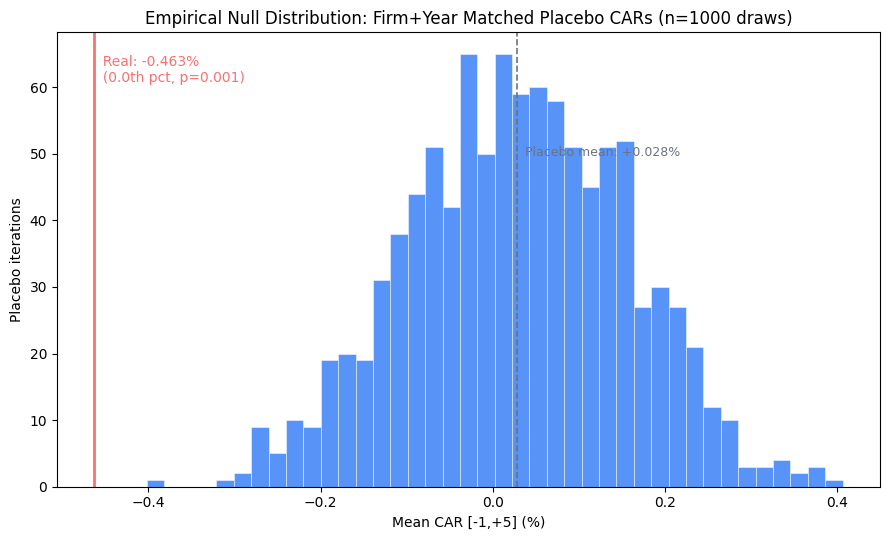

✓ Figure saved to placebo_test_distribution_v3.png


In [18]:
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.hist(valid_placebo * 100, bins=40, color='#3b82f6', alpha=0.85, edgecolor='white', linewidth=0.4)

ax.axvline(real_mean_car * 100, color='#f87171', linewidth=2)
ax.axvline(valid_placebo.mean() * 100, color='#6b7280', linewidth=1.2, linestyle='--')

label_ha = 'left' if real_mean_car < valid_placebo.mean() else 'right'
ax.text(real_mean_car * 100, ax.get_ylim()[1] * 0.95,
        f'  Real: {real_mean_car*100:+.3f}%\n  ({pct_rank:.1f}th pct, p={p_one_sided:.3f})',
        color='#f87171', fontsize=10, va='top', ha=label_ha)
ax.text(valid_placebo.mean() * 100, ax.get_ylim()[1] * 0.75,
        f'  Placebo mean: {valid_placebo.mean()*100:+.3f}%',
        color='#6b7280', fontsize=9, va='top')

ax.set_xlabel('Mean CAR [-1,+5] (%)')
ax.set_ylabel('Placebo iterations')
ax.set_title(f'Empirical Null Distribution: Firm+Year Matched Placebo CARs (n={PLACEBO_ITERS} draws)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'placebo_test_distribution_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 Figure saved to placebo_test_distribution_v3.png')


## Step 5 — CAR cumulation plot

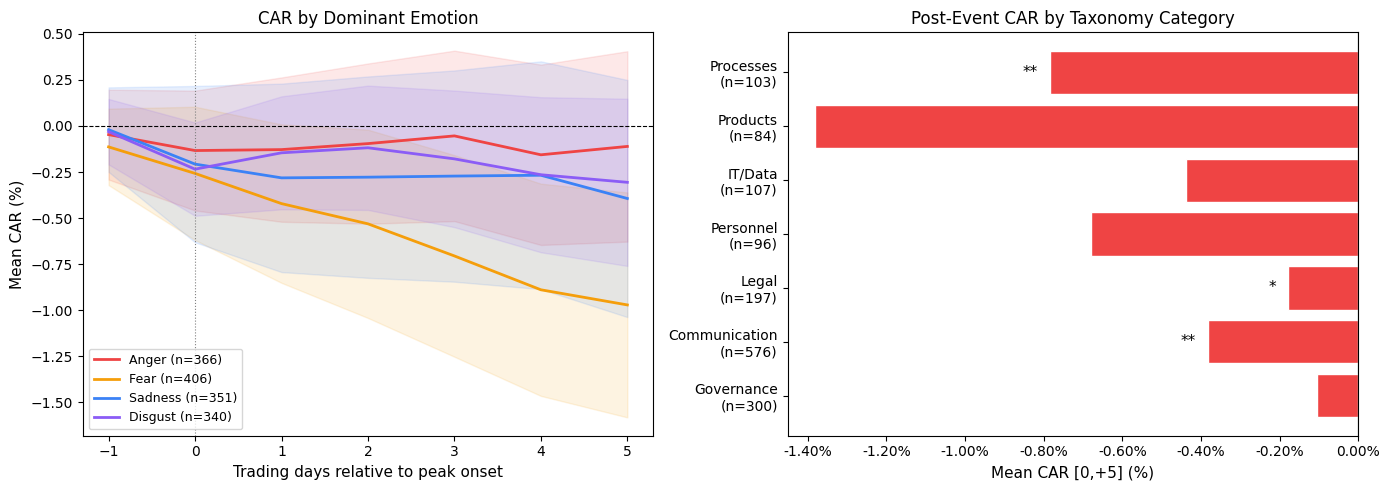

✓ Figure saved to results/phase_iv/car_plot_v3.png


In [19]:
day_labels = list(range(EVENT_WINDOW[0], EVENT_WINDOW[1] + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: CAR by dominant emotion
ax = axes[0]
emo_colours = {
    'anger': '#ef4444',
    'fear': '#f59e0b',
    'sadness': '#3b82f6',
    'disgust': '#8b5cf6',
}

for emo, colour in emo_colours.items():
    sub = event_df[event_df['dominant_emotion'] == emo]
    if len(sub) < 5:
        continue
    ar_mat = sub[ar_cols].values.astype(float)
    mean_ar = np.nanmean(ar_mat, axis=0)
    cum_car = np.nancumsum(mean_ar)
    n_valid = np.sum(~np.isnan(ar_mat), axis=0)
    se = np.nanstd(ar_mat, axis=0, ddof=1) / np.sqrt(np.maximum(n_valid, 1))
    cum_se = np.sqrt(np.nancumsum(se ** 2))

    ax.plot(day_labels, cum_car * 100, color=colour, lw=2,
            label=f'{emo.capitalize()} (n={len(sub):,})')
    ax.fill_between(day_labels,
                    (cum_car - 1.96 * cum_se) * 100,
                    (cum_car + 1.96 * cum_se) * 100,
                    alpha=0.12, color=colour)

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axvline(0, color='grey', lw=0.8, ls=':')
ax.set_xlabel('Trading days relative to peak onset', fontsize=11)
ax.set_ylabel('Mean CAR (%)', fontsize=11)
ax.set_title('CAR by Dominant Emotion', fontsize=12)
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

# Right: mean CAR [0,+5] by taxonomy category
ax2 = axes[1]
cat_order = ['Governance', 'Communication', 'Legal', 'Personnel',
             'IT/Data', 'Products', 'Processes']
cat_means = (
    event_df.groupby('primary_category')['car_post']
    .agg(['mean', 'count'])
    .reindex(cat_order)
    .dropna()
)
values = cat_means['mean'] * 100
labels = [f"{c}\n(n={int(cat_means.loc[c, 'count'])})" for c in cat_means.index]
bar_colours = ['#ef4444' if v < 0 else '#22c55e' for v in values]

bars = ax2.barh(labels, values, color=bar_colours, edgecolor='white')
ax2.axvline(0, color='black', lw=0.8)
ax2.set_xlabel('Mean CAR [0,+5] (%)', fontsize=11)
ax2.set_title('Post-Event CAR by Taxonomy Category', fontsize=12)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}%'))

# Annotate significance stars from summary_df
sig_map = {
    r['label'].replace('Category: ', ''): r
    for _, r in summary_df.iterrows()
    if r['label'].startswith('Category:')
}
for bar, cat in zip(bars, cat_means.index):
    row = sig_map.get(cat, {})
    p = row.get('wilcox_p', np.nan)
    s = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else ''))
    if s:
        x_pos = bar.get_width() + (0.03 if bar.get_width() >= 0 else -0.03)
        ax2.text(x_pos, bar.get_y() + bar.get_height() / 2,
                 s, va='center', ha='left' if bar.get_width() >= 0 else 'right',
                 fontsize=11, color='black')

plt.tight_layout()
fig_path = OUTPUT_DIR / 'car_plot_v3.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Figure saved to {fig_path}')

## Step 6 — Cross-sectional regression (robustness)

In [20]:
reg_df = event_df[['car_post', 'max_z', 'duration_days', 'dominant_emotion']].dropna().copy()

if len(reg_df) < 20:
    print('Regression skipped: insufficient non-null observations after filtering.')
else:
    m1 = smf.ols('car_post ~ max_z + duration_days', data=reg_df).fit(cov_type='HC3')
    print('Model 1: CAR ~ max_z + duration_days')
    tbl1 = m1.summary2().tables[1]
    stat_col = 't' if 't' in tbl1.columns else 'z'
    p_col = 'P>|t|' if 'P>|t|' in tbl1.columns else 'P>|z|'
    print(tbl1[['Coef.', 'Std.Err.', stat_col, p_col]].to_string())

    m2 = smf.ols('car_post ~ max_z + duration_days + C(dominant_emotion)', data=reg_df).fit(cov_type='HC3')
    print('\nModel 2: + dominant emotion FE')
    tbl2 = m2.summary2().tables[1]
    stat_col2 = 't' if 't' in tbl2.columns else 'z'
    p_col2 = 'P>|t|' if 'P>|t|' in tbl2.columns else 'P>|z|'
    print(tbl2[['Coef.', 'Std.Err.', stat_col2, p_col2]].to_string())

    if 'primary_category' in event_df.columns and event_df['primary_category'].notna().sum() >= 10:
        reg_df_cat = event_df[['car_post', 'max_z', 'duration_days', 'dominant_emotion', 'primary_category']].dropna().copy()
        if len(reg_df_cat) >= 20:
            m3 = smf.ols('car_post ~ max_z + duration_days + C(dominant_emotion) + C(primary_category)', data=reg_df_cat).fit(cov_type='HC3')
            print('\nModel 3: + taxonomy category FE')
            tbl3 = m3.summary2().tables[1]
            stat_col3 = 't' if 't' in tbl3.columns else 'z'
            p_col3 = 'P>|t|' if 'P>|t|' in tbl3.columns else 'P>|z|'
            print(tbl3[['Coef.', 'Std.Err.', stat_col3, p_col3]].to_string())

            with open(OUTPUT_DIR / 'regression_results_v3.txt', 'w') as f:
                f.write(m3.summary().as_text())
        else:
            print('\nModel 3 skipped: insufficient category-complete rows.')
            with open(OUTPUT_DIR / 'regression_results_v3.txt', 'w') as f:
                f.write(m2.summary().as_text())
    else:
        print('\nModel 3 skipped: no taxonomy-category data available in current peaks file.')
        with open(OUTPUT_DIR / 'regression_results_v3.txt', 'w') as f:
            f.write(m2.summary().as_text())

    print('\n✓ Regression summary saved')

Model 1: CAR ~ max_z + duration_days
                  Coef.  Std.Err.         z     P>|z|
Intercept      0.005423  0.010758  0.504146  0.614159
max_z         -0.001520  0.004266 -0.356418  0.721527
duration_days -0.002123  0.001347 -1.576405  0.114932

Model 2: + dominant emotion FE
                                   Coef.  Std.Err.         z     P>|z|
Intercept                       0.007262  0.010663  0.681106  0.495804
C(dominant_emotion)[T.disgust] -0.001924  0.002923 -0.658242  0.510382
C(dominant_emotion)[T.fear]    -0.007713  0.003816 -2.021537  0.043224
C(dominant_emotion)[T.sadness] -0.003002  0.003394 -0.884421  0.376469
max_z                          -0.000985  0.004321 -0.227932  0.819699
duration_days                  -0.002086  0.001332 -1.566269  0.117286

Model 3: + taxonomy category FE
                                      Coef.  Std.Err.         z     P>|z|
Intercept                          0.007549  0.010977  0.687726  0.491625
C(dominant_emotion)[T.disgust]    -0.

## Step 7 — Robustness: exclude financial crisis period

The 2008–2009 financial crisis introduces extreme market-wide volatility that may
inflate abnormal return variance for financial-sector firms. This cell re-runs the
main test excluding those two years.

In [21]:
print('Robustness: excluding 2008–2009 financial crisis period')
post_crisis = event_df[event_df['event_date'].dt.year >= 2010]
print(f'  Events in sample: {len(post_crisis):,} (dropped {len(event_df) - len(post_crisis):,})')

rows_robust = [summarise_cars(post_crisis, 'ALL PEAKS (ex. 2008-09)')]

print('\nBY TAXONOMY CATEGORY (ex. 2008-09)')
for cat in ['Governance', 'Communication', 'Legal', 'Personnel', 'IT/Data', 'Products', 'Processes']:
    sub = post_crisis[post_crisis['primary_category'] == cat]
    if len(sub) >= 10:
        rows_robust.append(summarise_cars(sub, f'Category: {cat}'))

robust_df = pd.DataFrame(rows_robust)
robust_df.to_csv(OUTPUT_DIR / 'event_study_robustness_v3.csv', index=False)
print('\n✓ Robustness table saved')

Robustness: excluding 2008–2009 financial crisis period
  Events in sample: 1,387 (dropped 76)
──────────────────────────────────────────────────────────────
  ALL PEAKS (ex. 2008-09)  (n=1,387)
  Mean CAR [-1,+5]  : -0.519%
  Mean CAR [ 0,+5]  : -0.464%
  % negative CARs   : 52.6%
  BMP t-stat        : -3.869***  (p=0.0001)
  Wilcoxon p (H1<0) : 0.0007***

BY TAXONOMY CATEGORY (ex. 2008-09)
──────────────────────────────────────────────────────────────
  Category: Governance  (n=283)
  Mean CAR [-1,+5]  : -0.280%
  Mean CAR [ 0,+5]  : -0.213%
  % negative CARs   : 49.8%
  BMP t-stat        : -0.663  (p=0.2538)
  Wilcoxon p (H1<0) : 0.4093
──────────────────────────────────────────────────────────────
  Category: Communication  (n=545)
  Mean CAR [-1,+5]  : -0.465%
  Mean CAR [ 0,+5]  : -0.410%
  % negative CARs   : 50.8%
  BMP t-stat        : -2.116**  (p=0.0174)
  Wilcoxon p (H1<0) : 0.0301**
──────────────────────────────────────────────────────────────
  Category: Legal  (n=183)
  

## Step 8 - External validity: CARs by sector and region

In [22]:
## Step 8 — External validity: CARs by sector and region

print('Step 8: External validity — subgroup analysis by sector and region')
print('='*62)

# Load MSCI constituent data for sector and region metadata
# msci_df columns used: Ticker, Location, and GICS Sector (check exact column name)
msci_df = pd.read_csv('data/00_raw/msci_world.csv', sep=';', skiprows=7)

# deduplicate MSCI data to ensure unique tickers (some tickers may appear multiple times due to share classes)
msci_df = msci_df.drop_duplicates(subset='Ticker', keep='first')

print(f'MSCI constituent columns: {msci_df.columns.tolist()}')

# Identify the sector column — adjust name if different
sector_col = next((c for c in msci_df.columns
                   if 'sector' in c.lower() or 'gics' in c.lower()), None)
print(f'Sector column identified: {sector_col}')

# Merge sector and region into event_df on original ticker
# msci_df uses the original (non-suffixed) ticker in 'Ticker' column
meta_cols = ['Ticker', 'Location']
if sector_col:
    meta_cols.append(sector_col)

event_enriched = event_df.merge(
    msci_df[meta_cols].rename(columns={
        'Ticker':    'ticker',
        'Location':  'region',
        sector_col:  'sector'
    } if sector_col else {
        'Ticker':   'ticker',
        'Location': 'region'
    }),
    on='ticker',
    how='left'
)

n_matched = event_enriched['region'].notna().sum()
print(f'\nEvents matched to MSCI metadata: {n_matched:,} / {len(event_enriched):,}')

# ── By GICS sector ────────────────────────────────────────────────────────────
if sector_col:
    print('\n' + '='*62)
    print('BY GICS SECTOR')

    rows_sector = []
    for sector in sorted(event_enriched['sector'].dropna().unique()):
        sub = event_enriched[event_enriched['sector'] == sector]
        if len(sub) >= 10:
            rows_sector.append(summarise_cars(sub, f'Sector: {sector}'))

    sector_df = pd.DataFrame(rows_sector)
    sector_df.to_csv(OUTPUT_DIR / 'event_study_by_sector.csv', index=False)
    print('✓ Sector results saved')

# ── By geographical region ────────────────────────────────────────────────────
# Group granular Location values into broader regions for interpretability
REGION_MAP = {
    'United States': 'North America',
    'Canada':        'North America',
    'United Kingdom':'Europe',
    'Germany':       'Europe',
    'France':        'Europe',
    'Switzerland':   'Europe',
    'Netherlands':   'Europe',
    'Sweden':        'Europe',
    'Denmark':       'Europe',
    'Finland':       'Europe',
    'Spain':         'Europe',
    'Belgium':       'Europe',
    'Italy':         'Europe',
    'Norway':        'Europe',
    'Japan':         'Asia-Pacific',
    'Australia':     'Asia-Pacific',
    'Hong Kong':     'Asia-Pacific',
    'Singapore':     'Asia-Pacific',
    'South Korea':   'Asia-Pacific',
}

event_enriched['broad_region'] = event_enriched['region'].map(REGION_MAP).fillna('Other')

print('\n' + '='*62)
print('BY GEOGRAPHICAL REGION')

rows_region = []
for reg in ['North America', 'Europe', 'Asia-Pacific', 'Other']:
    sub = event_enriched[event_enriched['broad_region'] == reg]
    if len(sub) >= 10:
        rows_region.append(summarise_cars(sub, f'Region: {reg}'))

region_df = pd.DataFrame(rows_region)
region_df.to_csv(OUTPUT_DIR / 'event_study_by_region.csv', index=False)
print('✓ Region results saved')

# ── Save enriched event_df for downstream use ─────────────────────────────────
event_enriched.to_parquet(OUTPUT_DIR / 'event_study_results_enriched.parquet', index=False)
print('✓ Enriched event data saved')

Step 8: External validity — subgroup analysis by sector and region
MSCI constituent columns: ['Ticker', 'Name', 'Sector', 'Asset Class', 'Market Value', 'Weight (%)', 'Notional Value', 'Quantity', 'Price', 'Location', 'Exchange', 'Currency', 'FX Rate', 'Accrual Date']
Sector column identified: Sector

Events matched to MSCI metadata: 1,463 / 1,463

BY GICS SECTOR
──────────────────────────────────────────────────────────────
  Sector: Communication  (n=319)
  Mean CAR [-1,+5]  : -0.365%
  Mean CAR [ 0,+5]  : -0.407%
  % negative CARs   : 50.8%
  BMP t-stat        : -1.254  (p=0.1054)
  Wilcoxon p (H1<0) : 0.0995*
──────────────────────────────────────────────────────────────
  Sector: Consumer Discretionary  (n=305)
  Mean CAR [-1,+5]  : -0.035%
  Mean CAR [ 0,+5]  : -0.028%
  % negative CARs   : 49.2%
  BMP t-stat        : -0.905  (p=0.1831)
  Wilcoxon p (H1<0) : 0.5157
──────────────────────────────────────────────────────────────
  Sector: Consumer Staples  (n=108)
  Mean CAR [-1,+5

## Step 8 — Paper table

In [23]:
def make_paper_table(df, caption, label):
    sig = lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else ''))
    rows = []
    for _, r in df.iterrows():
        rows.append({
            'Subsample'        : r['label'],
            'N'                : int(r['n']),
            'CAR [-1,+5]'      : f"{r['mean_car']*100:+.3f}%",
            'CAR [0,+5]'       : f"{r['mean_post']*100:+.3f}%",
            '% Negative'       : f"{r['pct_neg']:.1f}%",
            'BMP t'            : f"{r['bmp_t']:+.3f}{sig(r['bmp_p'])}",
            'Wilcoxon p'       : f"{r['wilcox_p']:.4f}{sig(r['wilcox_p'])}"
        })
    t = pd.DataFrame(rows)
    print(t.to_string(index=False))
    latex = t.to_latex(index=False, caption=caption, label=label, escape=False)
    return t, latex

print('MAIN TABLE')
main_t, main_latex = make_paper_table(
    summary_df, 'Event Study Results', 'tab:event_study')

print('\nROBUSTNESS TABLE (ex. 2008-09)')
rob_t, rob_latex = make_paper_table(
    robust_df, 'Event Study Robustness (excl. 2008–2009)', 'tab:event_study_robust')

with open(OUTPUT_DIR / 'paper_tables_v3.tex', 'w') as f:
    f.write(main_latex + '\n\n' + rob_latex)

main_t.to_csv(OUTPUT_DIR / 'paper_table_main_v3.csv', index=False)
rob_t.to_csv(OUTPUT_DIR / 'paper_table_robust_v3.csv', index=False)
print('\n✓ Tables saved (CSV + LaTeX)')
print('Note: * p<0.10  ** p<0.05  *** p<0.01')

MAIN TABLE
              Subsample    N CAR [-1,+5] CAR [0,+5] % Negative     BMP t Wilcoxon p
              ALL PEAKS 1463     -0.463%    -0.407%      52.4% -3.729***  0.0012***
         Emotion: anger  366     -0.111%    -0.064%      50.3%    -0.358     0.3094
          Emotion: fear  406     -0.971%    -0.858%      53.9% -2.949***  0.0016***
       Emotion: sadness  351     -0.394%    -0.374%      51.3%   -1.530*     0.2386
       Emotion: disgust  340     -0.306%    -0.275%      54.1%  -2.255**   0.0331**
   Category: Governance  300     -0.140%    -0.104%      49.7%    -0.558     0.5045
Category: Communication  576     -0.463%    -0.383%      51.2%  -2.062**   0.0244**
        Category: Legal  197     -0.225%    -0.179%      54.8%  -1.721**    0.0672*
    Category: Personnel   96     -0.844%    -0.681%      57.3%  -1.681**     0.1776
      Category: IT/Data  107     -0.270%    -0.437%      56.1%    -0.957     0.1232
     Category: Products   84     -1.817%    -1.383%      47.6%   